# Cluster 1 eRegulon Weighted GRS Ranking

This notebook ranks cluster-specific eRegulons with TF-target weights, FGOT gene-peak evidence, MAGMA gene risk, and peak-level SNP signal.


## Setup


In [1]:
from pathlib import Path
import sys

import pandas as pd
from IPython.display import display

UNIG_SRC = Path('/home/nas3/biod/yangchenghui/proj2/UniG_master/src')
PROJ = Path('/home/nas3/biod/yangchenghui/proj2/proj2_on_GBM/downstream_trait')
for path in [UNIG_SRC]:
    path_str = str(path)
    if path_str not in sys.path:
        sys.path.insert(0, path_str)

import unig as ug


In [2]:
trait_name = 'scz'
cluster_id = '1'

sumstats_file = Path('/home/nas3/biod/yangchenghui/proj2/gwas_data/Schizophrenia/ieu-b-5102.gsMap.sumstats.gz')
WORKDIR = PROJ / 'trait_localization_output/trait_GRS_cluster1_rank_workdir'
trait_dir = WORKDIR / trait_name
REGULATORY_DIR = PROJ / 'regulatory_result'

TF_GENE_CSV = REGULATORY_DIR / 'GBM_TF_Gene_Regulatory_Network_clean.csv'
GENE_PEAK_HG38 = REGULATORY_DIR / 'GBM_gene_CRE_Network_filtered.csv'
LIFT_MAPPING = REGULATORY_DIR / 'GBM_peak_liftover_hg38_to_hg19.tsv'
MAGMA_OUT = trait_dir / 'magma.genes.out'
MAGMA_GENE_LOC = Path('/home/nas3/biod/yangchenghui/proj2/MAGMA/NCBI37.3.gene.loc')
MAGMA_BIN = Path('/home/nas3/biod/yangchenghui/proj2/MAGMA/magma')
BFILE_ROOT = '/home/nas3/biod/yangchenghui/proj2/MAGMA/g1000_eur'
SNP_INFO = trait_dir / f'snp_info_{trait_name}.tsv'

RANKING_CSV = trait_dir / f'{trait_name}_cluster{cluster_id}_eRegulon_weighted_GRS_ranking.csv'
TARGET_SCORES_CSV = trait_dir / f'{trait_name}_cluster{cluster_id}_eRegulon_weighted_GRS_target_scores.csv'
GENE_MAP_CSV = trait_dir / 'magma_entrez_to_symbol.csv'

BUFFER = 0
MIN_TARGETS = 5
EDGE_WEIGHT_COL = 'weight'
TOP_N_REGULONS = 30
TOP_N_TARGETS = 20

trait_dir.mkdir(parents=True, exist_ok=True)

print(f'trait_name={trait_name}')
print(f'cluster_id={cluster_id}')
print(f'workdir={WORKDIR}')
print(f'output_dir={trait_dir}')


trait_name=scz
cluster_id=1
workdir=/home/nas3/biod/yangchenghui/proj2/proj2_on_GBM/downstream_trait/trait_localization_output/trait_GRS_cluster1_rank_workdir
output_dir=/home/nas3/biod/yangchenghui/proj2/proj2_on_GBM/downstream_trait/trait_localization_output/trait_GRS_cluster1_rank_workdir/scz


## Prepare Inputs


In [3]:
pval_file = trait_dir / f'{trait_name}_magma.pval'
snploc_file = trait_dir / f'{trait_name}.snp_loc'

if not SNP_INFO.exists():
    ug.trait.format_snp_info_for_grs(sumstats_file, BFILE_ROOT, SNP_INFO)

if not MAGMA_OUT.exists():
    ug.trait.prepare_magma_pval_file(sumstats_file, BFILE_ROOT, pval_file)
    ug.trait.prepare_magma_snploc(BFILE_ROOT, snploc_file)
    ug.trait.run_magma_gene_analysis(
        workdir=WORKDIR,
        trait_name=trait_name,
        magma_bin=MAGMA_BIN,
        bfile_root=BFILE_ROOT,
        gene_loc=MAGMA_GENE_LOC,
        snp_loc=snploc_file,
        pval_file=pval_file,
    )


[MAGMA] Step 1: SNP -> gene annotation
Welcome to MAGMA v1.10 (linux)
Using flags:
	--snp-loc /home/nas3/biod/yangchenghui/proj2/proj2_on_GBM/downstream_trait/trait_localization_output/trait_GRS_cluster1_rank_workdir/scz/scz.snp_loc
	--annotate window=10,10
	--gene-loc /home/nas3/biod/yangchenghui/proj2/MAGMA/NCBI37.3.gene.loc
	--out /home/nas3/biod/yangchenghui/proj2/proj2_on_GBM/downstream_trait/trait_localization_output/trait_GRS_cluster1_rank_workdir/scz/magma/scz

Start time is 22:07:03, Monday 31 Aug 2026

Starting annotation...
Reading gene locations from file /home/nas3/biod/yangchenghui/proj2/MAGMA/NCBI37.3.gene.loc... 
	adding window: 10000bp
	19427 gene locations read from file
	chromosome  1: 2016 genes
	chromosome  2: 1226 genes
	chromosome  3: 1050 genes
	chromosome  4: 745 genes
	chromosome  5: 856 genes
	chromosome  6: 1016 genes
	chromosome  7: 906 genes
	chromosome  8: 669 genes
	chromosome  9: 775 genes
	chromosome 10: 723 genes
	chromosome 11: 1275 genes
	chromosome

## Select Cluster TF Targets


In [4]:
tf_selection = ug.trait.select_cluster_tf_targets(
    tf_gene=TF_GENE_CSV,
    cluster_id=cluster_id,
    edge_weight_col=EDGE_WEIGHT_COL,
    min_targets=MIN_TARGETS,
)

cluster_tf_targets = tf_selection['cluster_tf_targets']
tested_tfs = tf_selection['tested_tfs']

print(f'retained TFs: {len(tested_tfs)}')
print(f'retained TF-target pairs: {len(cluster_tf_targets)}')
display(cluster_tf_targets.head())


retained TFs: 222
retained TF-target pairs: 2128


,TF,Target,TF_target_weight
0,AFF,CAMK2G,0.300726
1,AFF,DBI,0.200671
2,AFF,RPL23A,0.077616
3,AFF,RPL27,0.260407
4,AFF,RPL38,0.201968


## Build Cluster-Specific GRN


In [5]:
grn_result = ug.trait.build_cluster_fgot_grn(
    cluster_tf_targets=cluster_tf_targets,
    gene_peak=GENE_PEAK_HG38,
    lift_mapping=LIFT_MAPPING,
    cluster_id=cluster_id,
)

cluster_grn = grn_result['cluster_grn']

print(f'scoring rows: {len(cluster_grn)}')
display(cluster_grn.head())


scoring rows: 10283


,TF,Target,TF_target_weight,Regions,Pval,score_for_strength,has_cluster_gene_peak,gene_peak_strength_expected
0,AFF,CAMK2G,0.300726,chr10-75645799-75646299,0.050579,0.259303,True,1.296027
1,AFF,DBI,0.200671,chr2-120040614-120041114,0.061606,0.190932,True,1.210378
2,AFF,DBI,0.200671,chr2-120041533-120042033,0.059396,0.203953,True,1.226241
3,AFF,DBI,0.200671,chr2-120124995-120125495,0.054495,0.233997,True,1.263641
4,AFF,DBI,0.200671,chr2-120126145-120126645,0.060606,0.196787,True,1.217485


## Score Targets


In [6]:
gene_risk = ug.trait.read_magma_with_symbol(MAGMA_OUT, MAGMA_GENE_LOC, GENE_MAP_CSV)
all_regions = sorted(set(cluster_grn['Regions']))
peak_signal = ug.trait.build_peak_snp_signal(all_regions, SNP_INFO, buffer=BUFFER)

target_scores = ug.trait.target_grs_from_grn(cluster_grn, gene_risk, peak_signal)
target_scores.to_csv(TARGET_SCORES_CSV, index=False)

print(f'scored target rows: {len(target_scores)}')
print(f'target score table: {TARGET_SCORES_CSV}')
display(target_scores.head())


scored target rows: 1715
target score table: /home/nas3/biod/yangchenghui/proj2/proj2_on_GBM/downstream_trait/trait_localization_output/trait_GRS_cluster1_rank_workdir/scz/scz_cluster1_eRegulon_weighted_GRS_target_scores.csv


,TF,Target,TF_target_weight,Regions,Pval,score_for_strength,has_cluster_gene_peak,gene_peak_strength_expected,gene_peak_strength,SYMBOL,gene_risk,peak_snp_signal,top_snp,n_overlap_snps,target_GRS,weighted_target_GRS
0,AFF,CAMK2G,0.300726,chr10-75645799-75646299,0.050579,0.259303,True,1.296027,1.296027,CAMK2G,0.005116,0.120947,rs2633303,2,0.000802,0.000241
1,AFF,DBI,0.200671,chr2-120124995-120125495,0.054495,0.233997,True,1.263641,1.263641,DBI,0.402568,1.537771,rs2084202,6,0.782267,0.156979
2,AFF,RPL23A,0.077616,chr17-27075147-27075647,0.088153,0.053314,True,1.054761,1.054761,RPL23A,0.294256,1.113345,rs2070265,1,0.345548,0.026820
3,AFF,RPL27,0.260407,chr17-41173853-41174353,0.049428,0.266991,True,1.306029,1.306029,RPL27,0.568475,1.620717,rs2070835,1,1.203293,0.313346
4,AFF,RPL38,0.201968,chr17-72426872-72427372,0.075583,0.114735,True,1.121576,1.121576,RPL38,0.549074,1.735909,rs56824755,3,1.069022,0.215908


## Rank eRegulons


In [7]:
ranking = ug.trait.rank_weighted_eregulons(
    tested_tfs=tested_tfs,
    cluster_tf_targets=cluster_tf_targets,
    cluster_grn=cluster_grn,
    target_scores=target_scores,
    buffer=BUFFER,
    output_path=RANKING_CSV,
)

print(f'weighted GRS ranking: {RANKING_CSV}')
display(ranking.head(5))


weighted GRS ranking: /home/nas3/biod/yangchenghui/proj2/proj2_on_GBM/downstream_trait/trait_localization_output/trait_GRS_cluster1_rank_workdir/scz/scz_cluster1_eRegulon_weighted_GRS_ranking.csv


,RegulonID,RegulonName,weighted_eRegulon_GRS,n_targets_raw_cluster,n_targets_with_cluster_FGOT,n_scored_targets,sum_weighted_target_GRS,weight_l2_norm,mean_TF_target_weight,max_TF_target_weight,buffer,score_definition,weighted_GRS_rank
0,Regulon_221,ZNF75D,7.155795,12,12,11,6.577786,0.919225,0.262150,0.445424,0,sum(TF_target_weight * target_GRS) / sqrt(sum(...,1
1,Regulon_165,STAT1_STAT2,6.707995,19,19,14,5.798815,0.864463,0.219038,0.327677,0,sum(TF_target_weight * target_GRS) / sqrt(sum(...,2
2,Regulon_203,ZKSCAN5,6.451824,18,18,12,10.975257,1.701109,0.442599,0.950774,0,sum(TF_target_weight * target_GRS) / sqrt(sum(...,3
3,Regulon_68,IRF1,6.380265,22,22,19,7.462531,1.169627,0.240863,0.560637,0,sum(TF_target_weight * target_GRS) / sqrt(sum(...,4
4,Regulon_35,ESRRA,6.357680,9,9,7,5.838466,0.918333,0.320477,0.542414,0,sum(TF_target_weight * target_GRS) / sqrt(sum(...,5


## Plot Top eRegulons


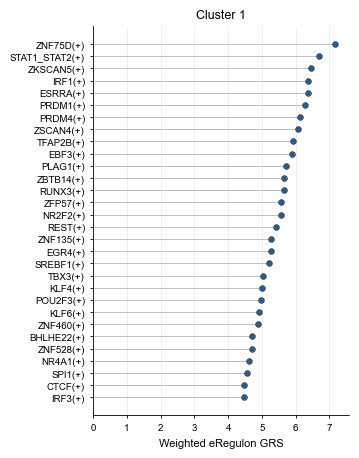

saved PDF: /home/nas3/biod/yangchenghui/proj2/proj2_on_GBM/downstream_trait/trait_localization_output/trait_GRS_cluster1_rank_workdir/scz/scz_cluster1_top30_eRegulon_weighted_GRS_lollipop.pdf


In [8]:
ranking = pd.read_csv(RANKING_CSV)
lollipop_pdf = trait_dir / f'{trait_name}_cluster{cluster_id}_top{TOP_N_REGULONS}_eRegulon_weighted_GRS_lollipop.pdf'

ug.trait.plot_weighted_eregulon_lollipop(
    ranking,
    output_path=lollipop_pdf,
    top_n=TOP_N_REGULONS,
    cluster_id=cluster_id,
)

print(f'saved PDF: {lollipop_pdf}')

## Inspect Key TF Targets


In [9]:
top_tfs = ['KLF4']
target_scores = pd.read_csv(TARGET_SCORES_CSV)
top_tf_targets = ug.trait.extract_top_tf_targets(target_scores, top_tfs=top_tfs, top_n=TOP_N_TARGETS)

cols = [
    'TF_weighted_GRS_rank', 'TF', 'Target', 'Regions', 'top_snp',
    'TF_target_weight', 'gene_peak_strength', 'gene_risk', 'peak_snp_signal',
    'n_overlap_snps', 'target_GRS', 'weighted_target_GRS',
]
display(top_tf_targets[cols][:5])


,TF_weighted_GRS_rank,TF,Target,Regions,top_snp,TF_target_weight,gene_peak_strength,gene_risk,peak_snp_signal,n_overlap_snps,target_GRS,weighted_target_GRS
0,1,KLF4,RPL31,chr2-101767765-101768265,rs12466496,0.781318,1.303915,1.093363,2.552668,2,3.639218,2.843387
1,1,KLF4,NDUFB4,chr3-120067453-120067953,rs4676696,0.291944,1.264677,1.644644,4.178052,1,8.690110,2.537023
2,1,KLF4,RPL19,chr17-37308287-37308787,rs535337,0.917226,1.143758,1.396921,1.355096,2,2.165090,1.985878
3,1,KLF4,RPL38,chr17-72426872-72427372,rs56824755,0.769219,1.121576,0.549074,1.735909,3,1.069022,0.822312
4,1,KLF4,UBB,chr17-16340181-16340681,rs7214366,0.624367,1.171479,0.387311,1.659158,4,0.752805,0.470027


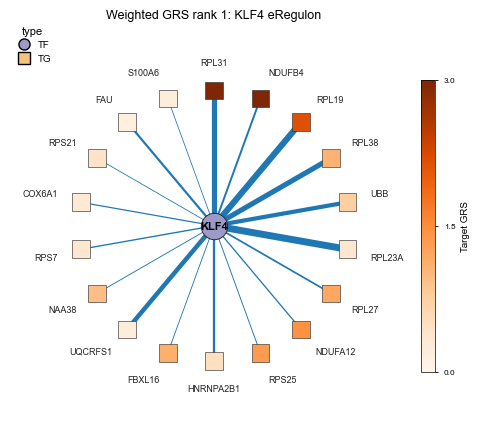

In [10]:
for grs_rank, tf_name in enumerate(top_tfs, start=1):
    pdf_path = trait_dir / (
        f'{trait_name}_cluster{cluster_id}_weightedGRSrank{grs_rank}_{tf_name}'
        '_network_TF_circle_TG_square.pdf'
    )
    net = ug.trait.plot_tf_target_network(
        target_scores,
        tf_name=tf_name,
        grs_rank=grs_rank,
        output_path=pdf_path,
        top_n=TOP_N_TARGETS,
    )